# FinMiniLM Eval — Base vs Fine-Tuned on Synthetic QA Pairs

## Goal
Evaluate base MiniLM vs fine-tuned MiniLM on `synthetic_qa_pdf.json` (20 hand-crafted QA pairs).
Each pair has ground-truth `chunk_id` — check if correct chunk appears in top-10 (Recall@10).

## Corpus
`fine_tuning/s4_corpus.csv` — all S4 chunks from 41 PDFs (built in FinS4_BuildCorpus.ipynb)

## Metric
- **Recall@10**: is the ground-truth chunk in the top-10 retrieved results?
- **MRR (Mean Reciprocal Rank)**: how high up is the correct chunk ranked?

In [1]:
import sys, os, json
from pathlib import Path

_root = Path().resolve()
for _ in range(5):
    if (_root / 'config.py').exists():
        break
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))

FINE_TUNE_DIR = 'fine_tuning'
S4_CORPUS     = os.path.join(FINE_TUNE_DIR, 's4_corpus.csv')
QA_PATH       = os.path.join('pdf_chunking', 'Results', 'synthetic_qa_pdf.json')
MODEL_BASE    = 'sentence-transformers/all-MiniLM-L6-v2'
MODEL_FT      = os.path.join(FINE_TUNE_DIR, 'minilm_finetuned')
RESULTS_DIR   = os.path.join(FINE_TUNE_DIR, 'Results')

os.makedirs(RESULTS_DIR, exist_ok=True)
assert os.path.exists(S4_CORPUS),  'Run FinS4_BuildCorpus.ipynb first!'
assert os.path.exists(MODEL_FT),   'Run FinMiniLM_FineTune.ipynb first!'
assert os.path.exists(QA_PATH),    'synthetic_qa_pdf.json not found!'
print('All paths OK')

All paths OK


In [2]:
import sys
!{sys.executable} -m pip install -q sentence-transformers faiss-cpu

In [3]:
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

print('Imports OK')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Cell 3 — Load Corpus + QA Pairs

In [4]:
corpus_df = pd.read_csv(S4_CORPUS)
print('S4 corpus: {:,} chunks'.format(len(corpus_df)))
print(corpus_df['category'].value_counts().to_string())

with open(QA_PATH) as f:
    qa_pairs = json.load(f)

qa_df = pd.DataFrame(qa_pairs)
print('\nSynthetic QA pairs: {}'.format(len(qa_df)))
print('Columns:', list(qa_df.columns))
print(qa_df['category'].value_counts().to_string())

# The QA pairs have chunk_id from the old S4 eval — we match by chunk_text instead
# since chunk_ids may differ between FinPDF_ChunkEval and FinS4_BuildCorpus
# Match: find corpus chunk with highest text overlap to qa pair's chunk_text
corpus_texts = corpus_df['text'].tolist()
corpus_ids   = corpus_df['chunk_id'].tolist()

# Map qa chunk_text → corpus chunk_id via first-80-char fingerprint
def find_chunk_id(qa_chunk_text, corpus_df):
    fingerprint = qa_chunk_text.strip()[:80].lower()
    for _, row in corpus_df.iterrows():
        if row['text'].strip()[:80].lower() == fingerprint:
            return row['chunk_id']
    return None

qa_df['matched_chunk_id'] = qa_df['chunk_text'].apply(
    lambda t: find_chunk_id(t, corpus_df)
)
matched = qa_df['matched_chunk_id'].notna().sum()
print('\nMatched QA pairs to corpus: {}/{}'.format(matched, len(qa_df)))
print('(Unmatched pairs will use chunk_text for soft matching during eval)')

S4 corpus: 14,493 chunks
category
Regulatory             8026
Payment_Industry       5658
Consumer_Protection     630
Synthetic_Policies      179

Synthetic QA pairs: 20
Columns: ['question', 'chunk_id', 'chunk_text', 'category', 'source_file']
category
Regulatory             5
Consumer_Protection    5
Payment_Industry       5
Synthetic_Policies     5

Matched QA pairs to corpus: 20/20
(Unmatched pairs will use chunk_text for soft matching during eval)


## Cell 4 — Evaluation Function (Recall@10 + MRR)

In [5]:
def evaluate_retrieval(model_path, corpus_texts, corpus_ids, qa_df, k=10, batch_size=128):
    """
    Build FAISS index → retrieve top-k for each QA question →
    check if ground-truth chunk appears in results.
    Ground truth matched by chunk_id (exact) or chunk_text fingerprint (soft).
    """
    print('Loading model: {}'.format(model_path))
    model = SentenceTransformer(model_path)

    print('  Encoding {:,} corpus chunks...'.format(len(corpus_texts)))
    corpus_embs = model.encode(corpus_texts, batch_size=batch_size,
                               normalize_embeddings=True, convert_to_numpy=True,
                               show_progress_bar=True)

    index = faiss.IndexFlatIP(corpus_embs.shape[1])
    index.add(corpus_embs.astype(np.float32))

    questions = qa_df['question'].tolist()
    print('  Encoding {} questions...'.format(len(questions)))
    q_embs = model.encode(questions, batch_size=batch_size,
                          normalize_embeddings=True, convert_to_numpy=True,
                          show_progress_bar=False)

    scores, indices = index.search(q_embs.astype(np.float32), k)

    recall_hits, mrr_scores, per_row = [], [], []

    for i, row in qa_df.iterrows():
        retrieved_ids   = [corpus_ids[idx] for idx in indices[i]]
        retrieved_texts = [corpus_texts[idx][:80].lower() for idx in indices[i]]
        gt_id           = row.get('matched_chunk_id')
        gt_text_fp      = row['chunk_text'].strip()[:80].lower()

        # Hit: exact chunk_id match OR text fingerprint match
        hit_rank = None
        for rank, (rid, rtxt) in enumerate(zip(retrieved_ids, retrieved_texts)):
            if (gt_id and rid == gt_id) or rtxt == gt_text_fp:
                hit_rank = rank + 1
                break

        recall_hits.append(1 if hit_rank else 0)
        mrr_scores.append(1.0 / hit_rank if hit_rank else 0.0)
        per_row.append({'question': row['question'][:60],
                        'category': row['category'],
                        'hit_rank': hit_rank,
                        'hit': bool(hit_rank)})

    return {
        'recall@10': round(float(np.mean(recall_hits)), 4),
        'mrr':       round(float(np.mean(mrr_scores)),  4),
        'per_row':   per_row,
    }

print('Evaluation function ready.')

Evaluation function ready.


## Cell 5 — Evaluate Base vs Fine-Tuned

In [6]:
eval_args = dict(corpus_texts=corpus_texts, corpus_ids=corpus_ids, qa_df=qa_df, k=10)

print('='*50)
print('Evaluating Base MiniLM...')
base_results = evaluate_retrieval(MODEL_BASE, **eval_args)
print('Base MiniLM  →  Recall@10: {:.4f}  |  MRR: {:.4f}'.format(
    base_results['recall@10'], base_results['mrr']))

print()
print('='*50)
print('Evaluating Fine-Tuned MiniLM...')
ft_results = evaluate_retrieval(MODEL_FT, **eval_args)
print('Fine-Tuned   →  Recall@10: {:.4f}  |  MRR: {:.4f}'.format(
    ft_results['recall@10'], ft_results['mrr']))

Evaluating Base MiniLM...
Loading model: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7124.58it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoding 14,493 corpus chunks...


Batches: 100%|██████████| 114/114 [01:30<00:00,  1.26it/s]


  Encoding 20 questions...
Base MiniLM  →  Recall@10: 0.5000  |  MRR: 0.3708

Evaluating Fine-Tuned MiniLM...
Loading model: fine_tuning/minilm_finetuned


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12012.72it/s]


  Encoding 14,493 corpus chunks...


Batches: 100%|██████████| 114/114 [01:47<00:00,  1.06it/s]

  Encoding 20 questions...
Fine-Tuned   →  Recall@10: 0.5000  |  MRR: 0.3563


## Cell 6 — Comparison Table + Chart + Save Results

  RETRIEVAL EVAL — Synthetic QA Pairs (n=20)
  Model                        Recall@10          MRR
----------------------------------------------------------
  Base MiniLM                     0.5000       0.3708
  Fine-Tuned MiniLM               0.5000       0.3563

Improvement from fine-tuning:
  Recall@10 : +0.0000
  MRR       : -0.0145

Per-question results (Fine-Tuned):
  Question                                                   Hit   Rank
----------------------------------------------------------------------
  What specific regulatory section must an institution co      ✗   MISS
  What timeframe is a remittance transfer provider requir      ✓      4
  What specific information is required to be disclosed b      ✓      1
  What timeframe is permitted for an institution to provi      ✓      1
  What specific condition must be met for the exclusion i      ✓      4
  What specific factors are considered when determining t      ✗   MISS
  What statements are included in the self-asses

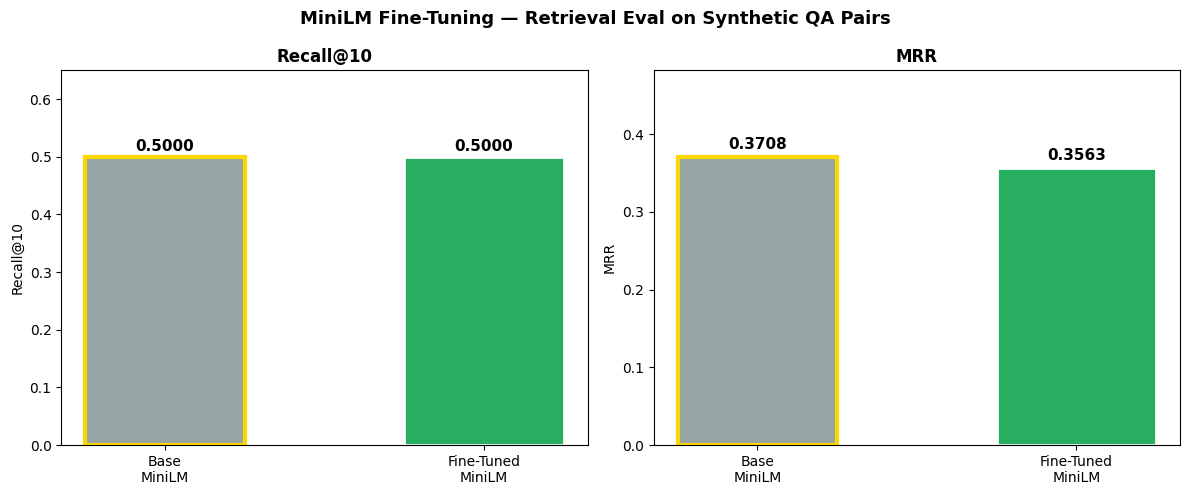

Saved: fine_tuning/Results/minilm_eval_comparison.png
Results saved: fine_tuning/Results/eval_results.json

Winner: Fine-Tuned MiniLM
Next step: integrate fine-tuned MiniLM into chatbot pipeline.


In [7]:
models   = ['Base\nMiniLM', 'Fine-Tuned\nMiniLM']
recalls  = [base_results['recall@10'], ft_results['recall@10']]
mrrs     = [base_results['mrr'],       ft_results['mrr']]
colors   = ['#95A5A6', '#27AE60']

# ── Print table ───────────────────────────────────────────────────────────────
print('='*58)
print('  RETRIEVAL EVAL — Synthetic QA Pairs (n=20)')
print('='*58)
print('  {:<25} {:>12} {:>12}'.format('Model', 'Recall@10', 'MRR'))
print('-'*58)
for name, r, m in zip(models, recalls, mrrs):
    label = name.replace('\n', ' ')
    print('  {:<25} {:>12.4f} {:>12.4f}'.format(label, r, m))
print('='*58)
print('\nImprovement from fine-tuning:')
print('  Recall@10 : {:+.4f}'.format(ft_results['recall@10'] - base_results['recall@10']))
print('  MRR       : {:+.4f}'.format(ft_results['mrr']       - base_results['mrr']))

# ── Per-question breakdown ────────────────────────────────────────────────────
print('\nPer-question results (Fine-Tuned):')
print('  {:<55} {:>6} {:>6}'.format('Question', 'Hit', 'Rank'))
print('-'*70)
for r in ft_results['per_row']:
    rank_str = str(r['hit_rank']) if r['hit_rank'] else 'MISS'
    print('  {:<55} {:>6} {:>6}'.format(r['question'][:55], '✓' if r['hit'] else '✗', rank_str))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('MiniLM Fine-Tuning — Retrieval Eval on Synthetic QA Pairs',
             fontsize=13, fontweight='bold')

for ax, vals, metric in [(axes[0], recalls, 'Recall@10'), (axes[1], mrrs, 'MRR')]:
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=2, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                '{:.4f}'.format(val), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(vals) * 1.3)
    best_i = vals.index(max(vals))
    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'minilm_eval_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

# ── Save JSON results ─────────────────────────────────────────────────────────
results = {
    'eval_set':         'synthetic_qa_pdf.json (20 pairs)',
    'base_minilm':      {'recall@10': base_results['recall@10'], 'mrr': base_results['mrr']},
    'finetuned_minilm': {'recall@10': ft_results['recall@10'],   'mrr': ft_results['mrr']},
    'improvement':      {
        'recall@10': round(ft_results['recall@10'] - base_results['recall@10'], 4),
        'mrr':       round(ft_results['mrr']       - base_results['mrr'],       4),
    },
    'winner': 'Fine-Tuned MiniLM' if ft_results['recall@10'] >= base_results['recall@10'] else 'Base MiniLM',
}
with open(os.path.join(RESULTS_DIR, 'eval_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved:', os.path.join(RESULTS_DIR, 'eval_results.json'))
print()
print('Winner:', results['winner'])
print('Next step: integrate fine-tuned MiniLM into chatbot pipeline.')